<a href="https://colab.research.google.com/github/gonzaloangaut/NeuralNetworks/blob/main/Practicos/redes_neuronales_2023_practico_11_Angaut.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Perceptrón multicapa

El estado de la $i$-ésima neurona en la $l$-ésima capa de un perceptrón multicapa se denota por $x_{li}$.
En particular, $x_{0i}$ denota el estado de la $i$-ésima neurona de entrada y, si la red tiene $1+L$ capas, $x_{Li}$ el estado de la $i$-ésima neurona de salida.
Dichos estados se relacionan según

$$
x_{l+1,i}=g(h_{l+1,i})
$$

y

$$
h_{l+1,i}=\sum_j (w_l)_{ij}x_{lj}
$$

Aquí, $h_{l+1,i}$ denota el campo local percibido por la $i$-ésima neurona en la $l+1$-ésima capa y $(w_l)_{ij}$ denota el "axón" que nace en la $j$-ésima neurona de la $l$-ésima capa y hace sinápsis con la $i$-ésima neurona de la $(l+1)$-ésima capa.
Más aún, $g:\mathbb{R}\ni h\to g(h)\in \mathbb{R}$ denota una función de activación a elección, e.j. una ReLU

$$
g(h)
=
\left\{
\begin{array}{ll}
h, & h>0 \\
0, & c.c.
\end{array}
\right.
$$

Por convención, la $0$-ésima neurona de la $l$-ésima capa siempre matiene su estado fijo en $x_{l0}=-1$.
De esta manera, usamos a $-(w_l)_{i0}$ en remplazo del umbral de activación $u_{l+1,i}$ de la $i$-ésima neurona en la $(l+1)$-ésima capa.

## Error cuadrático medio

Considere una serie de ejemplos de *entrada* y *salida* para que la red aprenda.
Más precisamente, sea $e_{ki}$ la $i$-ésima entrada y $s_{kj}$ la $j$-ésima salida del $k$-ésimo ejemplo.

Entrenar la red, corresponde a reducir el error que comete la red sobre el conjunto de ejemplos.
Para ello, considere el error cuadrático medio definido por

$$
E =\frac{1}{2}\sum_{ki}(v_{Lki}-s_{ki})^2
$$

donde

$$
v_{lki} = x_{li}
$$

cuando la entrada de la red se evalúa en el correspondiente ejemplo, i.e. cuando

$$
x_{0i} = e_{ki}
$$

## Entrenamiento por descenso por el gradiente

En lo que sigue, simplificaremos la notación escribiendo $w_{lij}$ en vez de $(w_{l})_{ij}$, pero siempre recordando que $w_{lij}$ no representa una componénte de un tensor de grado 3, porque los pesos sinápticos vienen dados por una serie de matrices $w_0$, ..., $w_{L-1}$ de tamaños diferentes y entradas $(w_l)_{ij}$.

Para reducir el error cuadrático medio $E$, se necesita calcular el gradiente de $E$ respecto de los pesos sinápticos $w_{lij}$.
Entonces, hay que calcular las componentes

$$
\frac{\partial E}{\partial w_{lij}}
$$

de dicho gradiente, para luego ajustarlos según la fórmula

$$
w_{lrt} \leftarrow w_{lrt} - \eta \frac{\partial E}{\partial w_{lrt}}
$$

donde el signo menos se usa porque se quiere minimizar el error y $0<\eta\ll 1$ representa la tasa de entrenamiento.

Para calcular las componentes del gradiente, conviene comenzar por los pesos sinápticos relacionando la penúltima capa y la última capa.
Para ello, notamos que

\begin{eqnarray}
\frac{\partial E}{\partial w_{(L-1)rt}}
&=&
\sum_{ki}
(v_{Lki}-s_{ki})
g'(h_{Lki})
\frac{\partial h_{Lki}}{\partial w_{(L-1)rt}}
\\
&=&
\sum_{ki}
(v_{Lki}-s_{ki})
g'(h_{Lki})
\sum_j
\frac{\partial w_{(L-1)ij}}{\partial w_{(L-1)rt}}
v_{(L-1)kj}
\\
&=&
\sum_{k}
(v_{mkr}-s_{kr})
g'(h_{Lkr})
v_{(L-1)kt}
\\
&=:&
\sum_{k}
d_{Lkr}
v_{(L-1)kt}
\end{eqnarray}

donde $h_{lki}$ denota el campo local percibido por la $i$-ésima neurona en la $l$-ésima capa ante el $k$-ésimo ejemplo, y en la última línea se introdujo

$$
d_{Lkr}
:=
g'(h_{Lkr})
(v_{Lkr}-s_{kr})
$$

por conveniencia notacional.

Ahora procedemos con el cálculo de la derivada del error respecto a un peso sináptico de una capa intermedia.
Elegimos la $(L-q)$-ésima capa para algún valor de $q\leq L$, y encontramos que

\begin{eqnarray}
\frac{\partial E}{\partial w_{(L-q)rt}}
&=&
\sum_{ki}
(v_{Lki}-s_{ki})
g'(h_{Lki})
\frac{\partial h_{Lki}}{\partial w_{(L-q)rt}}
\\
&=&
\sum_{ki}
d_{Lki}
\frac{\partial h_{Lki}}{\partial w_{(L-q)rt}}
\\
&=&
\sum_{ki}
d_{Lki}
\sum_{j}
w_{(L-1)ij}
\frac{\partial v_{(L-1)kj}}{\partial w_{(L-q)rt}}
\\
&=&
\sum_{kij}
d_{Lki}
w_{(L-1)ij}
g'(h_{(L-1)kj})
\frac{\partial h_{(L-1)kj}}{\partial w_{(L-q)rt}}
\\
&=&
\sum_{kj}
g'(h_{(L-1)kj})
\bigg(
\sum_i
d_{Lki}
w_{(L-1)ij}
\bigg)
\frac{\partial h_{(L-1)kj}}{\partial w_{(L-q)rt}}
\\
&=:&
\sum_{kj}
d_{(L-1)kj}
\frac{\partial h_{(L-1)kj}}{\partial w_{(L-q)rt}}
\end{eqnarray}

donde, en la última línea, se introdujo

$$
d_{(L-1)kj}
:=
g'(h_{(L-1)kj})
\bigg(
\sum_i
d_{Lki}
w_{(L-1)ij}
\bigg)
$$

por conveniencia notacional.

Luego, nos enfocamos en la derivada

\begin{eqnarray}
\frac{\partial h_{(L-1)kj}}{\partial w_{(L-q)rt}}
&=&
\sum_p
w_{(L-2)jp}
\frac{\partial v_{(L-1)kp}}{\partial w_{(L-q)rt}}
\\
&=&
\sum_p
w_{(L-2)jp}
g'(h_{(L-2)kp})
\frac{\partial h_{(L-2)kp}}{\partial w_{(L-q)rt}}
\end{eqnarray}

y así obtenemos que

\begin{eqnarray}
\frac{\partial E}{\partial w_{(L-q)rt}}
&=&
\sum_{kj}
d_{(L-1)kj}
\sum_p
w_{(L-2)jp}
g'(h_{(L-2)kp})
\frac{\partial h_{(L-2)kp}}{\partial w_{(L-q)rt}}
\\
&=&
\sum_{kp}
g'(h_{(L-2)kp})
\bigg(
\sum_j
d_{(L-1)kj}
w_{(L-2)jp}
\bigg)
\frac{\partial h_{(L-2)kp}}{\partial w_{(L-q)rt}}
\\
&=&
\sum_{kp}
d_{(L-2)kp}
\frac{\partial h_{(L-2)kp}}{\partial w_{(L-q)rt}}
\end{eqnarray}

donde, nuevamente, se introduce la notación

$$
d_{(L-2)kp}
=
g'(h_{(L-2)kp})
\bigg(
\sum_j
d_{(L-1)kj}
w_{(L-2)jp}
\bigg)
$$

por conveniencia notacional.

Esto puede continuarse hasta que se llega a

\begin{eqnarray}
\frac{\partial E}{\partial w_{(L-q)rt}}
&=&
\sum_{ki}
d_{(L-q+1)ki}
\frac{\partial h_{(L-q+1)ki}}{\partial w_{(L-q)rt}}
\\
&=&
\sum_{ki}
d_{(L-q+1)ki}
\sum_j
\frac{\partial w_{(L-q)ij}v_{(L-q)kj}}{\partial w_{(L-q)rt}}
\\
&=&
\sum_{ki}
d_{(L-q+1)ki}
\sum_j
v_{(L-q)kj}
\frac{\partial w_{(L-q)ji}}{\partial w_{(L-q)rt}}
\\
&=&
\sum_{k}
d_{(L-q+1)kr}
v_{(L-q)kt}
\end{eqnarray}

donde se ha utilizado que $v_{k(L-q)t}$ no depende de $w_{(L-q)rt}$, puesto que sólo depende de conecciones sinápticas $w_{lij}$ de capas $l < L-q$, y que

$$
d_{(L-q+1)kr}
=
g'(h_{(L-q+1)kr})
\bigg(
\sum_i
d_{(L-q+2)ki}
w_{(L-q+1)ir}
\bigg)
$$

o, alternativamente, que

$$
d_{lkr}
=
g'(h_{lkr})
\bigg(
\sum_i
d_{(l+1)ki}
w_{lir}
\bigg)
$$

para todo $l\in \{1,2,...,m\}$.
Finalmente, este procedimiento concluye para $q=L$, en donde se obtiene

\begin{eqnarray}
\frac{\partial E}{\partial w_{0rt}}
&=&
\sum_{k}
d_{1kr}
v_{0kt}
\end{eqnarray}

y

$$
d_{1kr}
=
g'(h_{1kr})
\bigg(
\sum_i
d_{2ki}
w_{1ir}
\bigg)
$$

## Backpropagation

En la sección anterior se derivó la forma de calcular las componentes del gradiente de $E$ como función de los pesos sinápticos $w_0$,...,$w_{L-1}$.
A continuación se indica un algoritmo para calcularlos de manera eficiente.
El mismo consiste en iterar sobre epocas de entrenamiento, y en cada una de ellas ejecutar el siguiente procedimiento:

1. Una forward pass. Esto consiste en evaluar la red en cada entrada $e_{ki}$ para calcular las cantidades $h_{lki}$ y $v_{lki}$ para todo $k$, $l$ e $i$ usando

  $$
  v_{0ki} = x_{ki}
  $$

  y

  $$
  h_{(l+1)ki} = \sum_j w_{lij} v_{lkj}
  $$

  $$
  v_{lki} = g(h_{lki})
  $$

  de manera progresiva en $l\in \{0,1,...,L-1\}$.
  De ahí el nombre *forward pass*.

2. Una backward pass. Esto consiste en utilizar lo calculado en el item anterior para calcular las cantiades $d_{lkr}$ y actualizar los pesos $w_{lrt}$ para todo $l$, $k$, $r$ y $t$ correspondientes, usando

  $$
  d_{Lkr}
  :=
  g'(h_{Lkr})
  (v_{Lkr}-s_{kr})
  $$

  luego

  $$
  d_{lkr}
  =
  g'(h_{lkr})
  \bigg(
  \sum_i
  d_{(l+1)ki}
  w_{lir}
  \bigg)
  $$

  y

  $$
  w_{lrt} -= \eta \sum_k d_{(l+1)kr} v_{lkt}
  $$

  de manera progresiva en $l\in \{L-1,L-2,...,1\}$, y finalmente

  $$
  w_{0rt} -= \eta \sum_k d_{1kr} v_{0kt}
  $$

  De ahí el nombre *backward pass*.

El anterior procedimiento debe iterarse varias veces hasta que la convergencia de los los pesos sinápticos hacia valores óptimos alcance un criterio deseado.

## **Ejercicio 1)** Importando librerías

Importe las librerías `numpy` para operar con arrays, `scipy` para utilizar rutinas de algebra lineal y `matplotlib.pyplot` para graficar.

In [ ]:
import numpy as np
import scipy as sp
import scipy.linalg as linalg
import matplotlib.pyplot as plt

## **Ejercicio 2)**

**a)** Importe la función `make_classification` de scikit-learn para generar un conjunto de ejemplos a aprender. Para ello, escriba

    from sklearn.datasets import make_classification

**b)** Genere un conjunto de 30 ejemplos (`n_samples=30`). Los inputs deben ser vectores con dos coordenadas (`n_features=2`). Los outputs deben poseer tres valores (`n_classes=3`).

Este procedimiento generará una matriz $\tilde{e}_{ki}$, indicando la $i$-ésima entrada del $k$-ésimo ejemplo, y un vector $\tilde{s}_{k}$ indicando la clase  del $k$-ésimo ejemplo.

**c)** Grafique los ejemplos en el plano, utilizando distintos colores para distintas clases.
Más precisamente, para cada $k$, grafique un círculo de radio arbitrarion en la coordenadas $x=\tilde{e}_{k0}$ e $y=\tilde{e}_{k1}$, y de un color indicado por $s_{k}$.
Utilice, por ejemplo, el color rojo para la clase 1, el color azul para la clase 2 y el color verde para la clase 3.

In [ ]:
# 2.a)
from sklearn.datasets import make_classification

In [ ]:
# 2.b)

q = 30 # numero de ejemplos
f = 2 # numero de features
c = 3 # numero de clases

ee,ss = make_classification(
    n_samples=q,
    n_features=f,
    n_classes=c,
    n_redundant=0,
    class_sep=3,
    n_clusters_per_class=1
)

In [ ]:
ee, ss # aca podemos ver que estamos dando ejemplos para 2 neuronas de entradas y las salidas pueden ser 0, 1 ó 2.

(array([[-3.71943553, -2.32701148],
        [ 4.25887944, -4.43213437],
        [-2.91253342, -2.75246766],
        [-2.97325164, -2.98061938],
        [ 2.43515209, -3.02048993],
        [ 3.02683513, -2.83419054],
        [ 2.62760555, -2.473846  ],
        [-3.95948633,  1.03738458],
        [ 2.14154469, -2.83097804],
        [-2.81788445,  3.31804564],
        [ 4.69203873, -4.45619822],
        [-2.60195116,  4.06883242],
        [-3.22434404,  2.45490605],
        [-2.88354686,  3.18547964],
        [-2.46719902,  3.76080097],
        [-2.95439044,  2.94620698],
        [-3.08089163,  2.65484079],
        [-2.3522728 , -4.03695337],
        [ 5.00118178, -4.35755585],
        [-4.28368332, -2.79799757],
        [ 3.58368432, -3.2423334 ],
        [-2.87747331,  2.89679316],
        [-1.69936688, -3.51983762],
        [-5.48917739, -2.63202646],
        [ 3.17669478, -2.94741312],
        [-4.21128922, -1.95665317],
        [-1.03223993,  0.11874506],
        [-2.47827129, -2.401

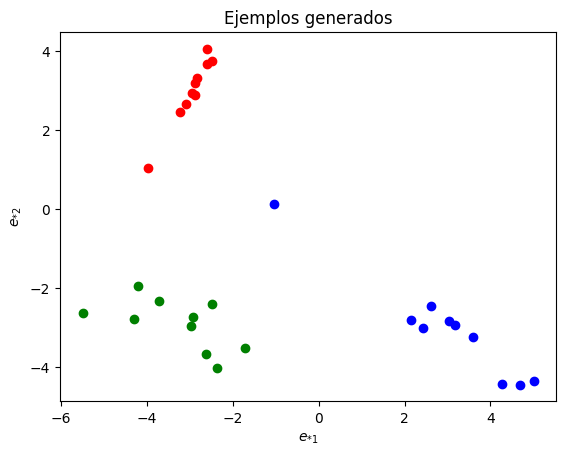

In [ ]:
# 2.c)

# grafiquemos en el plano e1 vs e2

color = {0:'red',1:'blue', 2:'green'} # si la salida es -1 entonces rojo, si es 1 entonces azul
for k in range(q): # para todos los ejemplos
    plt.scatter([ee[k,0]],[ee[k,1]],c=color[ss[k]]) # ploteo el valor de la primera entrada vs el de la segunda con el color correspondiente a su salida
plt.title("Ejemplos generados")
plt.xlabel("$e_{*1}$")
plt.ylabel("$e_{*2}$")
plt.show()

## **Ejercicio 3)** Implementando y entrenando una red neuronal feedforward con una capa oculta

**a)** Transforme los ejemplos generados en el ejercicio anterior a un formato adecuado. Para ello:

  **i)** Con el fin de agregar las neuronas artificiales que permitan representar umbrales de activación $u_{(l+1)i}$ usando pesos sinápticos $w_{li0}$, cree una matriz de entradas $e_{ki}$ que extienda la original $\tilde{e}_{ki}$ con una nueva columna de valores $-1$.
  Más precisamente, defina $e_{k0}=-1$ para todo $k$ y $e_{k(i+1)} = \tilde{e}_{ki}$ para todo $i\in \{0,...,n_l-1\}$ donde $n_l$ es el número de neuronas en la capa $l$, incluyendo la capa de entrada $l=0$.

  **ii)** Transforme el vector de categorias $\tilde{s}_k\in \{0,1,2,...,c-1\}$ en una matriz de clasificación $s_{ki}\in \{0,1\}$, i.e. una matriz tal que $s_{ki}=1$ si $\tilde{s}_k=i$ y $s_{ki}=0$ en caso contrario.

**b)** Implemente una red feedforward de $1+L=3$ capas (una de entrada, una oculta y una de salida).
El vector $n$ del número de neuronas de cada capa, la función de activación $g$ y su derivada $g'$, tienen que poder especificarse.

**c)** Utilizando $2$ neuronas en la capa de entrada, $5$ en la intermedia y $3$ en la de salida, cree y entrene una red neuronal feedforward con los ejemplos generados en el ejercicio 2.
Antes de entrenar, recuerde inicializar los pesos sinápticos $w_{lij}$ con valores aleatorios en $[-1,1]$.
Recuerde, además, agregar en las capas que corresponda las neuronas extra que permitan usar pesos sinápticos para representar los umbrales de activación.
Con ello, el vector de número de neuronas por capa debería resultar $n=(n_0,n_1,n_2)=(3,6,3)$.

Para entrenar, pruebe distintos valores de $\eta$ y distintos números de épocas. De todas formas, le recomendamos $\eta=0.0001$ y entrenar durante $1000$ épocas.

**d)** Grafique, comparativamente, los ejemplos y la clasificación encontrada por la red.
Utilice círculos de color de fondo indicando las clases originales de los ejemplos y de color del borde indicando la clasificación generada por la red.

In [ ]:
# 3.a)

# extendamos la matriz de entradas "e" agregando una columna con -1

umbral = -np.ones((q,1+f)) # 1+f columnas todas con -1, desde la 2da en adelante las vamos a redefinir

e = umbral
e[:,1] = ee[:, 0]
e[:,2] = ee[:, 1]
e

array([[-1.        , -3.71943553, -2.32701148],
       [-1.        ,  4.25887944, -4.43213437],
       [-1.        , -2.91253342, -2.75246766],
       [-1.        , -2.97325164, -2.98061938],
       [-1.        ,  2.43515209, -3.02048993],
       [-1.        ,  3.02683513, -2.83419054],
       [-1.        ,  2.62760555, -2.473846  ],
       [-1.        , -3.95948633,  1.03738458],
       [-1.        ,  2.14154469, -2.83097804],
       [-1.        , -2.81788445,  3.31804564],
       [-1.        ,  4.69203873, -4.45619822],
       [-1.        , -2.60195116,  4.06883242],
       [-1.        , -3.22434404,  2.45490605],
       [-1.        , -2.88354686,  3.18547964],
       [-1.        , -2.46719902,  3.76080097],
       [-1.        , -2.95439044,  2.94620698],
       [-1.        , -3.08089163,  2.65484079],
       [-1.        , -2.3522728 , -4.03695337],
       [-1.        ,  5.00118178, -4.35755585],
       [-1.        , -4.28368332, -2.79799757],
       [-1.        ,  3.58368432, -3.242

In [ ]:
# ahora transformemos s en una matriz de clasificación:
# una matriz tal que s_ki=1 si ss_k=i y s_ki=0 en caso contrario
# la matriz s_ki va a ser q*3(c)
s=np.zeros((q,c))

for k in range(0, q):
  for i in range(0, c):
    if ss[k]==i:
      s[k][i]=1
    else:
      s[k][i]=0

ss, s

(array([2, 1, 2, 2, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 2, 1, 2, 1, 0,
        2, 2, 1, 2, 1, 2, 0, 2]),
 array([[0., 0., 1.],
        [0., 1., 0.],
        [0., 0., 1.],
        [0., 0., 1.],
        [0., 1., 0.],
        [0., 1., 0.],
        [0., 1., 0.],
        [1., 0., 0.],
        [0., 1., 0.],
        [1., 0., 0.],
        [0., 1., 0.],
        [1., 0., 0.],
        [1., 0., 0.],
        [1., 0., 0.],
        [1., 0., 0.],
        [1., 0., 0.],
        [1., 0., 0.],
        [0., 0., 1.],
        [0., 1., 0.],
        [0., 0., 1.],
        [0., 1., 0.],
        [1., 0., 0.],
        [0., 0., 1.],
        [0., 0., 1.],
        [0., 1., 0.],
        [0., 0., 1.],
        [0., 1., 0.],
        [0., 0., 1.],
        [1., 0., 0.],
        [0., 0., 1.]]))

In [ ]:
# 3.b)
"""
En este inciso vamos a armar la red neuronal de 3 capas suponiendo que el numero de neuronas en cada capa puede ser especificado y la función
de activación g y su derivada también
"""
# definimos el entrenamiento para cada epoca

def train_epoch(e, s, n, w, g, dg, eta=0.0001):
  # primero defino algunos parámetros que me serán útiles
  m = len(n)-1

  # v es una matriz que contiene matrices, 1 para cada capa. Tiene filas = # de ejemplos, columnas = # de neuronas en dicha capa
  # esta matriz será lo que calcula la neurona. v_lki=g(h_lki) con v_0ki=x_ki
  v = [np.zeros((q,n[l])) for l in range(0, 1+m)] # incluye l=0 de la entrada

  # h tambien contiene matrices pero no la primera pues h_0ki no está definido (pues h es la suma pesada de las neuronas anteriores)
  h = [None] + [np.zeros((q,n[l])) for l in range(1,1+m)]

  # lo mismo para d
  d = [None] + [np.zeros((q,n[l])) for l in range(1,1+m)]


  #forward pass
  v[0][:,:] = e # uso la condición v_0ki=e_ki de la primera entrada

  for l in range(0, m): # vemos capa por capa hacia adelante
    h[l+1][:,:] = (w[l]@v[l].T).T # @ es producto escalar. La primera traspuesta es para poder hacer el producto escalar y
    # la segunda es para que correspondan los indices: v_(l+1)ki = sum_j w_lij v_lkj
    v[l+1][:,:] = g(h[l+1])

  #backward pass
  # primero calculo el d de la última capa
  y = v[m]-s # y_kr = v_mkr-s_kr, diferencia entre lo que da y debería dar
  d[m] = dg(h[m])*y # ultima capa d_{mkr} = g'(h_mkr)y_{kr}
  E = np.sum(y*y) # Error
  for l in range(m-1, 0, -1): # voy de atras hacia adelante, empezando por la ante ultima capa
    d[l] = dg(h[l])*(d[l+1]@w[l]) # d_lkj = g'(h_lkj)*(sum_i d_(l+1)ki w_lij)
    w[l] -= eta*d[l+1].T@v[l] # w_lij -= eta*\sum_k d_(l+1)ki v_lkj
  w[0] -= eta*d[1].T@v[0] # lo mismo solo que no entra en el for
# devolvemos w que es lo que queremos encontrar y E para finalizar en algun momento teniendo en cuenta el error
  return E, w

In [ ]:
# 3. c)
"""
Ahora vamos a usar lo definido en el inciso anterior.
Vamos a aplicarlo en una red con 2 neuronas de entrada, 5 en la intermedia y 3 en la salida con los ejemplos generados en 2.
w_ij van a ser aleatorios entre -1 y 1.
Además, necesitamos agregar las neuronas de umbral, entonces n=(3, 6, 3) en lugar de (2, 5, 3)
1000 epocas
"""
nint=5
n=(f+1, nint+1, c)
m = len(n)-1
w = [2*np.random.random((n[l+1],n[l]))-1 for l in range(m)] # Lista de pesos sinápticos, w[l][i,j]
# np.random.random() da valores entre 0 y 1, por eso 2*()-1

# además tenemos que poner que el peso es siempre -1 para una neurona de cada "sinapsis"
for l in range(len(w)):
  w[l][:,0] = -1
w # la primera matriz es 3*6 (entrada con capa oculta) y la segunda 6*3 (capa oculta con salida)

[array([[-1.        , -0.63974712,  0.54042457],
        [-1.        , -0.63691467, -0.94351387],
        [-1.        , -0.84457873,  0.01833007],
        [-1.        ,  0.11079304, -0.05247947],
        [-1.        , -0.64819545, -0.85969279],
        [-1.        ,  0.1696348 , -0.25018313]]),
 array([[-1.        ,  0.31132738,  0.48495816, -0.6439655 , -0.24129783,
          0.36533584],
        [-1.        ,  0.99688606,  0.59607383,  0.80903705, -0.53356715,
         -0.97729702],
        [-1.        , -0.41225979,  0.88264987,  0.29220878,  0.28384884,
         -0.62453902]])]

In [ ]:
# definamos la función g que vamos a usar. Usemos la relu
def g(h):
  if h>0.0:
    return h
  else:
    return 0.0
def dg(h):
  if h>0.0:
    return 1.0
  else:
    return 0.0
g = np.vectorize(g)
dg = np.vectorize(dg)

In [ ]:
# Ahora ya vamos a hacer el entrenamiento

print("ERROR")
eta=0.0001
for epoca in range(0, 1000):
  E, w = train_epoch(e, s, n, w, g, dg, eta=eta)
  # vamos a imprimir el error cada 100 epocas para ver si va disminuyendo:
  if epoca%100==0 or epoca==0:
    print(epoca, eta, E)
  #print(E,w)

ERROR
0 0.0001 120.9789104839772
100 0.0001 20.28256454408711
200 0.0001 20.25594795103193
300 0.0001 20.249538030039997
400 0.0001 20.244899431188962
500 0.0001 20.241013971248627
600 0.0001 20.237480652938554
700 0.0001 20.23412811574803
800 0.0001 20.230880964229165
900 0.0001 20.227705674959335


In [ ]:
# 3.d)
# ahora ya tenemos w, veamos si los ejemplos son correctos
# armo una matriz x que va a tener que ver con lo que hace cada capa
x = [np.zeros(n[l]) for l in range(len(n))]
def eval(e, w, g):
  x[0][:] = e # la primera matriz seran las entradas
  for l in range(len(w)):
     x[l+1][:] = g(w[l]@x[l]) #la matriz siguiente será la función g evaluada en el w que calculamos

  # a nosotros nos importa solo los valores de salida, o sea x en su última linea
  return x[m]

for ejemplo in range(0, q):
  x_pred = eval(e[ejemplo,:], w, g)
  print(x_pred)

print("")
print(s)

[0.         0.         0.88823878]
[0. 0. 0.]
[0.        0.        0.8900839]
[0.        0.        0.9620371]
[0. 0. 0.]
[0. 0. 0.]
[0. 0. 0.]
[0. 0. 0.]
[0. 0. 0.]
[0. 0. 0.]
[0. 0. 0.]
[0. 0. 0.]
[0. 0. 0.]
[0. 0. 0.]
[0. 0. 0.]
[0. 0. 0.]
[0. 0. 0.]
[0.         0.         1.16543758]
[0. 0. 0.]
[0.         0.         1.09989884]
[0. 0. 0.]
[0. 0. 0.]
[0.         0.         0.92824423]
[0.         0.         1.22728235]
[0. 0. 0.]
[0.         0.         0.85635104]
[0. 0. 0.]
[0.         0.         0.73031436]
[0. 0. 0.]
[0.         0.         1.10513282]

[[0. 0. 1.]
 [0. 1. 0.]
 [0. 0. 1.]
 [0. 0. 1.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [1. 0. 0.]
 [0. 1. 0.]
 [1. 0. 0.]
 [0. 1. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [0. 0. 1.]
 [0. 1. 0.]
 [0. 0. 1.]
 [0. 1. 0.]
 [1. 0. 0.]
 [0. 0. 1.]
 [0. 0. 1.]
 [0. 1. 0.]
 [0. 0. 1.]
 [0. 1. 0.]
 [0. 0. 1.]
 [1. 0. 0.]
 [0. 0. 1.]]


Text(0, 0.5, '$e_{*2}$')

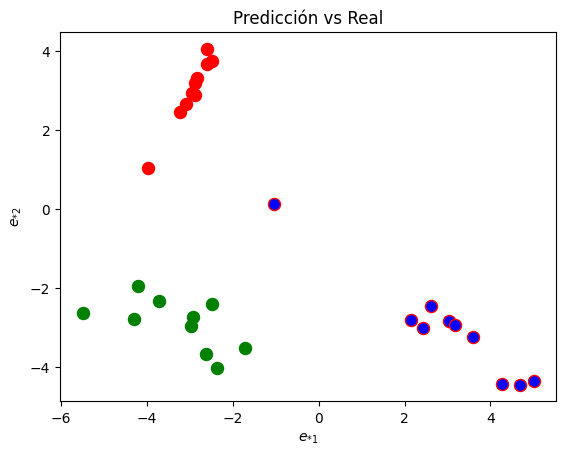

In [ ]:
# notemos que en cada caso hay uno de los 3 que es mayor. Vamos a hacer que el que es mayor sea el que se prende mientras que el resto queda apagado.
for k in range(q):
  c_true = color[ss[k]]
  c_pred = color[np.argmax(eval(e[k,:], w, g))] # prediccion
  plt.scatter([e[k,1]],[e[k,2]],color=c_true,marker='.',edgecolors=c_pred,linewidth=1,s=300)
plt.title("Predicción vs Real")
plt.xlabel("$e_{*1}$")
plt.ylabel("$e_{*2}$")